In [1]:
import numpy as np

from aqua.utils import *
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

10000
[[200. 210. 400. 410. 600. 610. 800. 810.]]
BIN1: (10000,)
CORR COEFF: 0.9958133244157168
NORM DOT: 0.9961427646480469
(10000,)
DOT: 0.021209361736737996
NORM 1: 0.20042484443956665
NORM 2: 0.1062317801794919
SCHREIBER: 0.9961427646480469


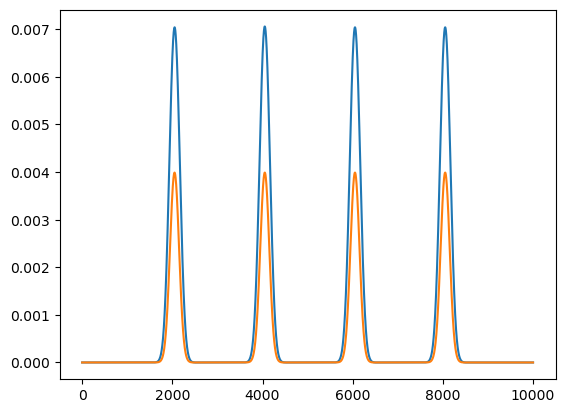

In [ ]:
T = 1
dt = 0.1
N_iter = int(1000*T/dt)
print(N_iter)

spikes1 = np.array([[2, 2.1, 4, 4.1, 6, 6.1, 8, 8.1]])*100
print(spikes1)
spikes2 = np.array([[2.05, 4.05, 6.05, 8.05]])*100


bin1 = binarise_spikes(spikes1, dt, N_iter)[0]
bin2 = binarise_spikes(spikes2, dt, N_iter)[0]

#plt.plot(bin1[0, :])
#plt.plot(bin2[0, :])

sigma = 10 # ms
filt_bin1 = gaussian_filter(bin1, sigma = sigma/dt)
filt_bin2 = gaussian_filter(bin2, sigma = sigma/dt)

plt.plot(filt_bin1)
plt.plot(filt_bin2)


print(f'CORR COEFF: {np.corrcoef(filt_bin1, filt_bin2)[0, 1]}')

dot = np.dot(filt_bin1, filt_bin2)
print(f'NORM DOT: {dot/(np.linalg.norm(filt_bin1)*np.linalg.norm(filt_bin2))}')

schreiber = schreiber_similarity(bin1, bin2, sigma = sigma, dt = dt)
print(f'SCHREIBER: {schreiber}')

